In [2]:
#Logistic Regression

#Load & Data Exploration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#Load dataset
cancer = load_breast_cancer()
X_c = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_c = cancer.target

print("Dataset shape:", X_c.shape)
print("Target Classes:", cancer.target_names) # 0 = malignant, 1 = benign
print("\n Distribution of target classes:")
print(pd.Series(y_c).value_counts())

#Split Data
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

#Feature Scaling
scaler = StandardScaler()
X_c_train_scaled = scaler.fit_transform(X_c_train)
X_c_scaled = scaler.transform(X_c_test)

Dataset shape: (569, 30)
Target Classes: ['malignant' 'benign']

 Distribution of target classes:
1    357
0    212
Name: count, dtype: int64


In [3]:
#Train with Regularization
logreg = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
logreg.fit(X_c_train_scaled, y_c_train)

#Predict probabilities and classes
y_c_train_pred = logreg.predict(X_c_train_scaled)
y_c_train_proba = logreg.predict_proba(X_c_train_scaled)[:, 1]

y_c_test_pred = logreg.predict(X_c_scaled)
y_c_test_proba = logreg.predict_proba(X_c_scaled)[:, 1]

#Evaluation
print("Logistic Regression Results")
print(f"Training Accuracy: {accuracy_score(y_c_train, y_c_train_pred):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_c_test, y_c_test_pred):.4f}")
print(f"Testing Precision: {precision_score(y_c_test, y_c_test_pred):.4f}")
print(f"Testing Recall: {recall_score(y_c_test, y_c_test_pred):.4f}")
print(f"Testing F1 Score: {f1_score(y_c_test, y_c_test_pred):.4f}")
print(f"Testing AUC-ROC: {roc_auc_score(y_c_test, y_c_test_proba):.4f}")

Logistic Regression Results
Training Accuracy: 0.9868
Testing Accuracy: 0.9737
Testing Precision: 0.9722
Testing Recall: 0.9859
Testing F1 Score: 0.9790
Testing AUC-ROC: 0.9974


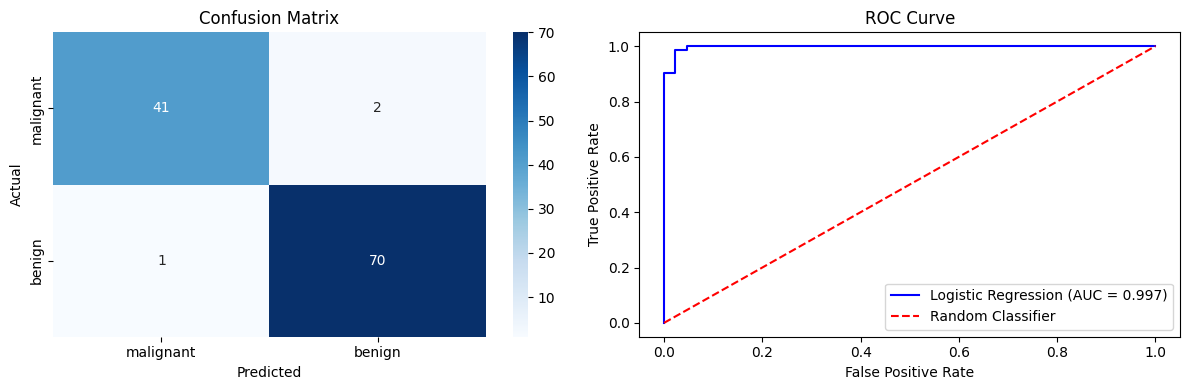

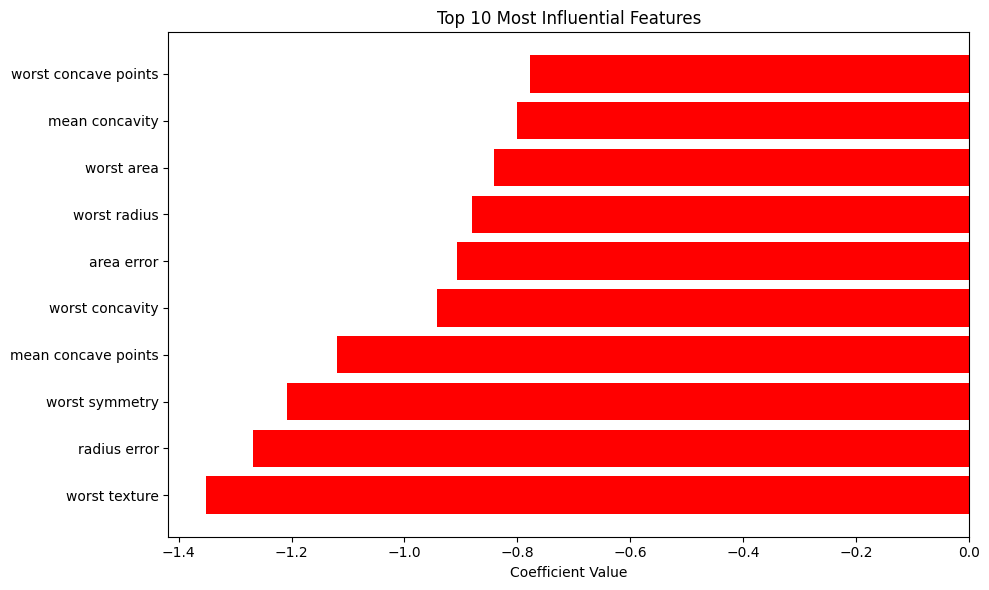

In [4]:
#Confusion Matrix
cm = confusion_matrix(y_c_test, y_c_test_pred)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

#ROC Curve
fpr, tpr, thresgolds = roc_curve(y_c_test, y_c_test_proba)
auc = roc_auc_score(y_c_test, y_c_test_proba)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, 'b-', label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0,1],[0,1], 'r--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

#Interpretation of model (10 most  coefficients)
coef_df = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Coefficient': logreg.coef_[0]
})

coef_df['Abs_Koef'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Koef', ascending=False).head(10)

plt.figure(figsize=(10, 6))
colors = ['red' if c < 0 else 'green' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Top 10 Most Influential Features')
plt.tight_layout()
plt.show()


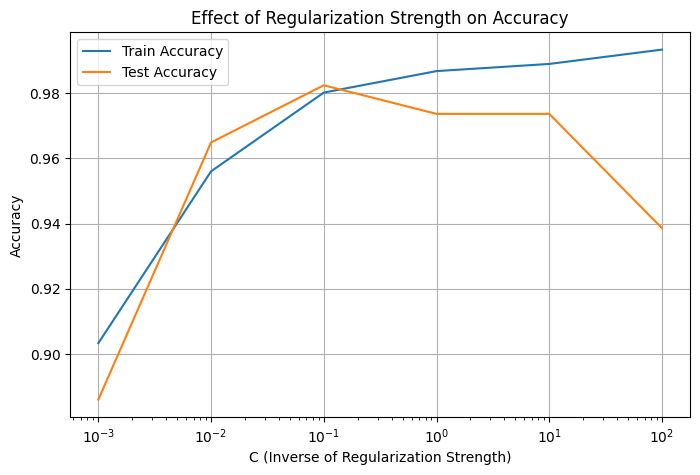

C kecil = strong regularization (underfitting risk)
C besar = weak regularization (overfitting risk)


In [6]:
# Coba berbagai nilai C (inverse of regularization strength)
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
train_acc = []
test_acc = []

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
    lr.fit(X_c_train_scaled, y_c_train)
    train_acc.append(accuracy_score(y_c_train, lr.predict(X_c_train_scaled)))
    test_acc.append(accuracy_score(y_c_test, lr.predict(X_c_scaled)))

plt.figure(figsize=(8, 5))
plt.semilogx(C_values, train_acc, label="Train Accuracy")
plt.semilogx(C_values, test_acc, label="Test Accuracy")
plt.xlabel("C (Inverse of Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Effect of Regularization Strength on Accuracy")
plt.legend()
plt.grid(True)
plt.show()

print("C kecil = strong regularization (underfitting risk)")
print("C besar = weak regularization (overfitting risk)")

In [22]:
#Case Study : A bank wants to predict is a customer will default on a loan based on their income and credit score. 

#Making Simple Dataset
np.random.seed(42)
n_samples = 1000
income = np.random.normal(50000, 15000, n_samples)  # Average income with some variance
debt_ratio = np.random.uniform(0, 0.5, n_samples)  # Debt ratio between 0 and 0.5
late_payments = np.random.poisson(2, n_samples)  # Average of 2 late payments

#Making Label (default if dangerous combination of features)
prob_default = 1 / (1 + np.exp(-(-2 - 0.00003*income + 5*debt_ratio + 0.3*late_payments)))
default = (prob_default > 0.5).astype(int)

#Training Logistic Regression
X_bank = np.column_stack([income, debt_ratio, late_payments])
X_bank_train, X_bank_test, y_bank_train, y_bank_test = train_test_split(X_bank, default, test_size=0.2, random_state=42)

scaler_bank = StandardScaler()
X_bank_train_scaled = scaler_bank.fit_transform(X_bank_train)
X_bank_test_scaled = scaler_bank.transform(X_bank_test)

bank_model = LogisticRegression()
bank_model.fit(X_bank_train_scaled, y_bank_train)

#Predict new customer
new_customer = np.array([[60000, 0.25, 1]]) # Income, Debt Ratio, Late Payments
new_customer_scaled = scaler_bank.transform(new_customer)
prob = bank_model.predict_proba(new_customer_scaled)[0, 1]

print(f"Case Study: Detecting Loan Default")
print(f"Model Accuracy: {accuracy_score(y_bank_test, bank_model.predict(X_bank_test_scaled)):.3f}")
print(f"Probability new customer will default: {prob:.2%}")
print(f"Recommendation: {'REJECT' if prob > 0.5 else 'APPROVE'}")

Case Study: Detecting Loan Default
Model Accuracy: 0.985
Probability new customer will default: 0.00%
Recommendation: APPROVE



Threshold = 0.3
[[41  2]
 [ 0 71]]
Precision: 0.9726
Recall: 1.0000
F1 Score: 0.9861


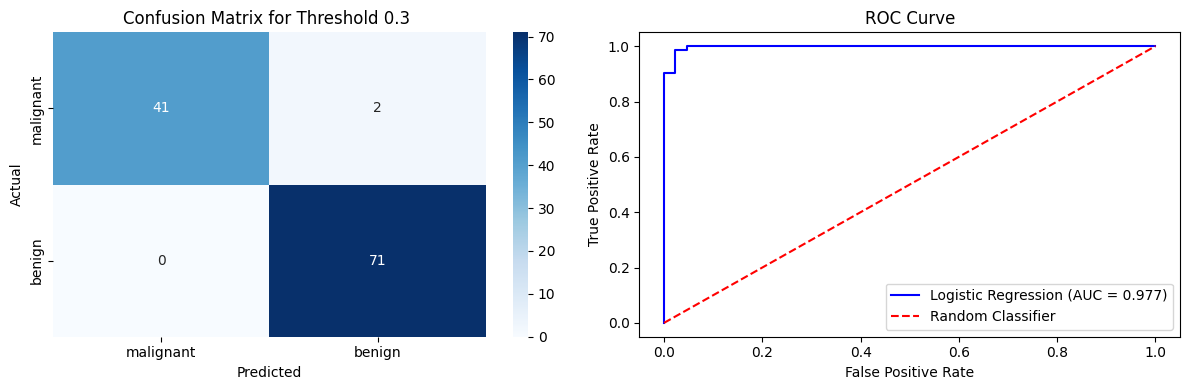

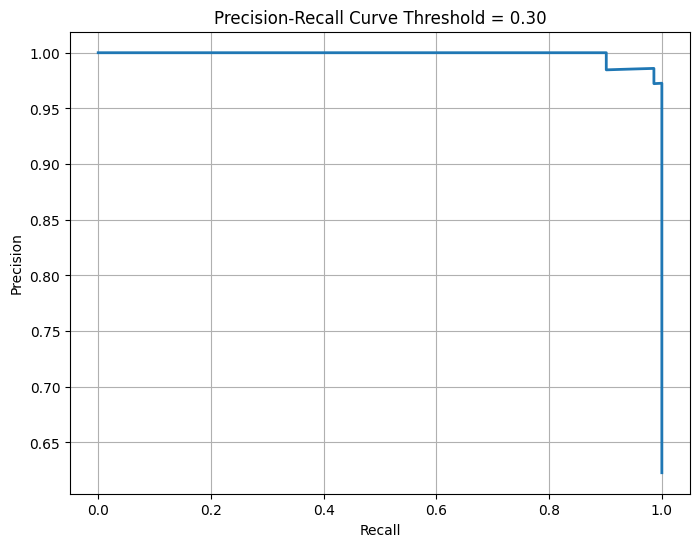


Threshold = 0.5
[[41  2]
 [ 1 70]]
Precision: 0.9722
Recall: 0.9859
F1 Score: 0.9790


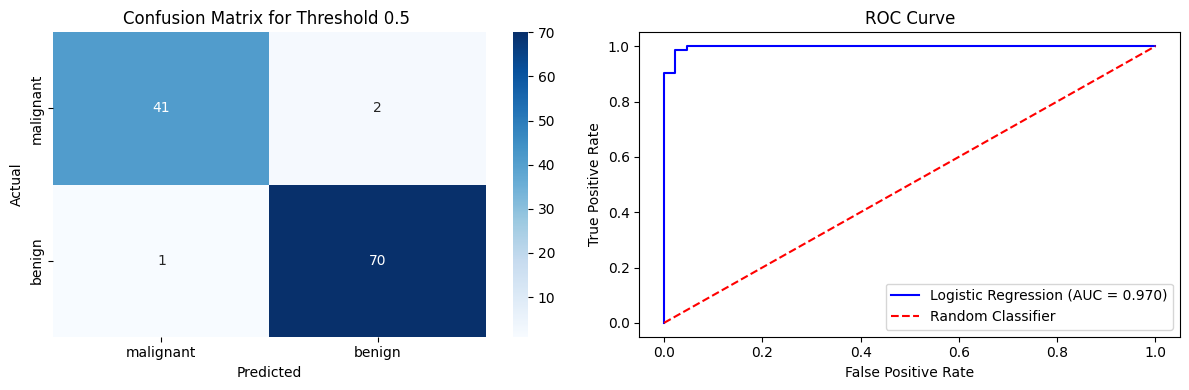

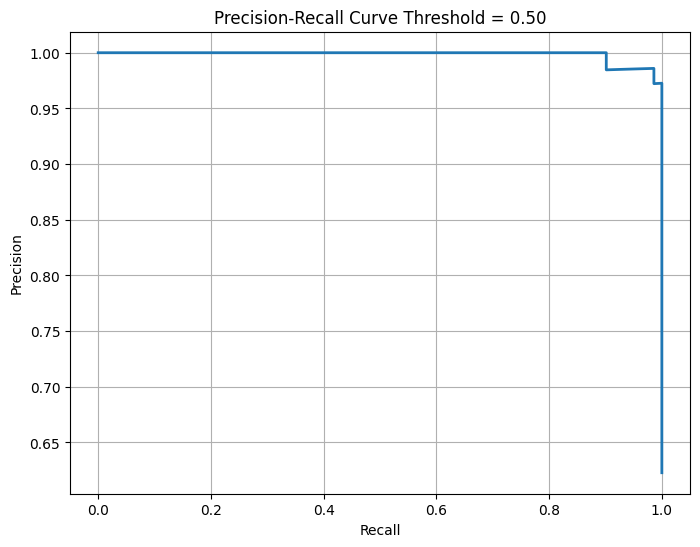


Threshold = 0.7
[[42  1]
 [ 4 67]]
Precision: 0.9853
Recall: 0.9437
F1 Score: 0.9640


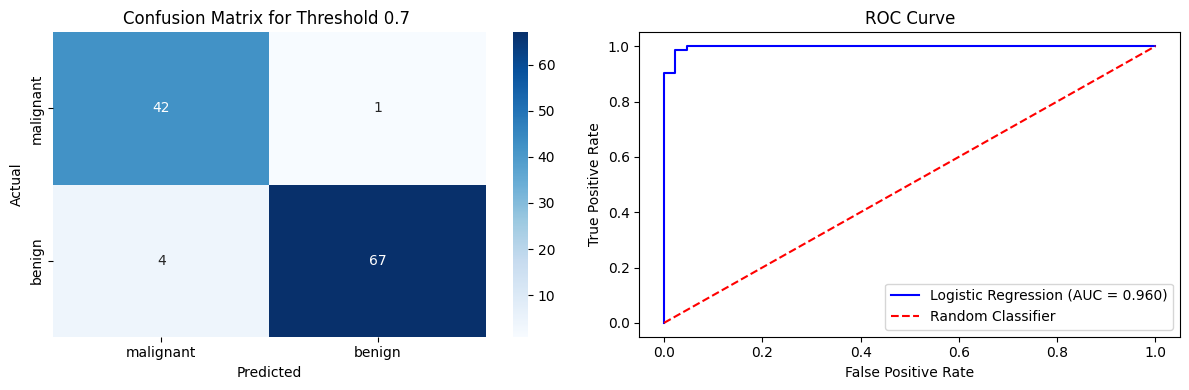

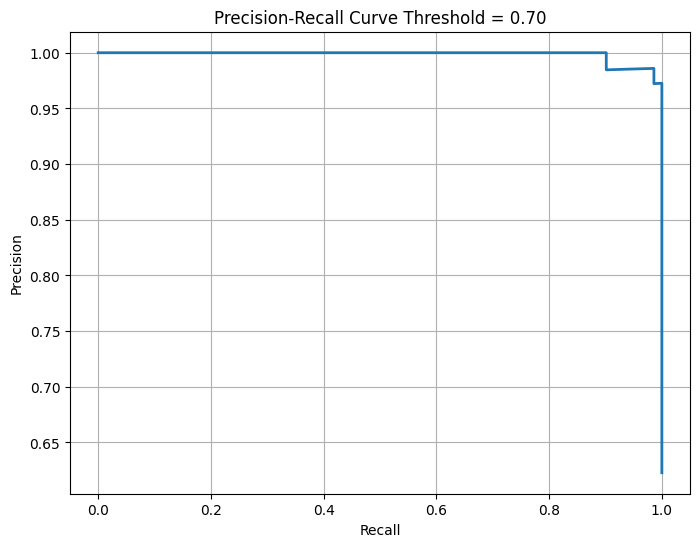

C:\Users\abrah\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Threshold = 1
[[43  0]
 [71  0]]
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


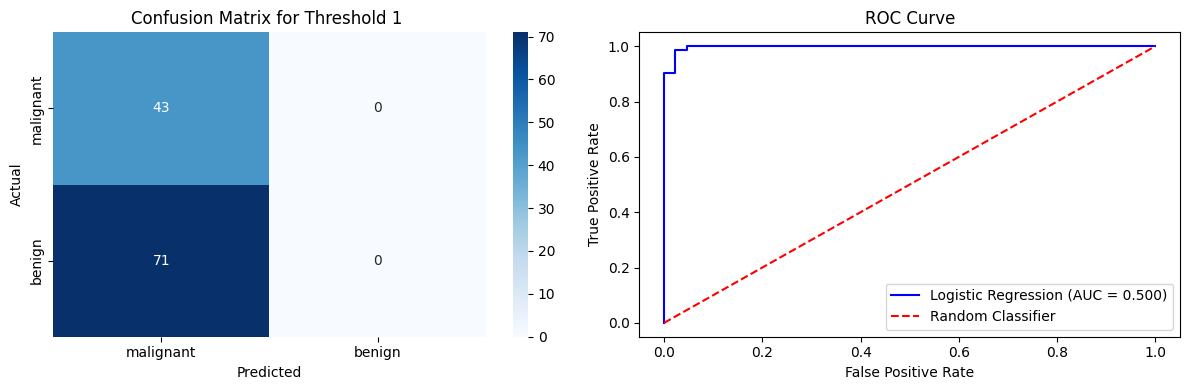

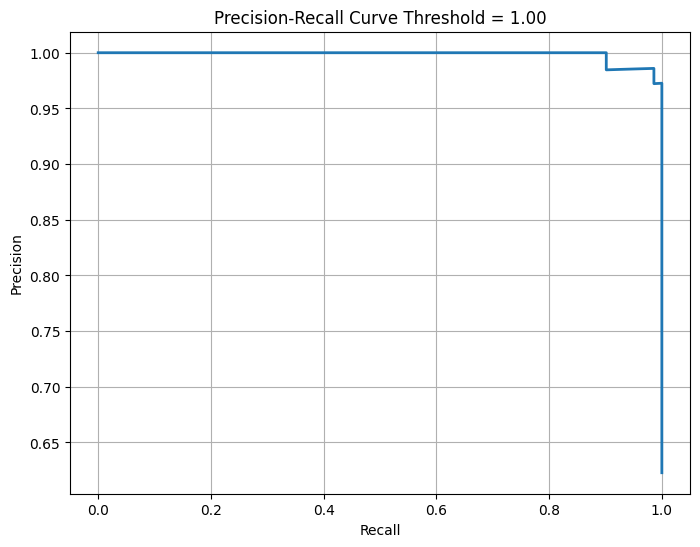

In [19]:
from sklearn.metrics import precision_recall_curve

thresholds = [0.3, 0.5, 0.7, 1]

for threshold in thresholds:

    y_pred = (
        y_c_test_proba >= threshold
    ).astype(int)

    precision = precision_score(y_c_test, y_pred)
    recall = recall_score(y_c_test, y_pred)
    f1 = f1_score(y_c_test, y_pred)
    cm = confusion_matrix(y_c_test, y_pred)

    print(f"\nThreshold = {threshold}")

    print(
        cm
    )


    #Plot Confusion Matrix
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for Threshold {threshold} ')

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    #ROC Curve
    fpr, tpr, thresgolds = roc_curve(y_c_test, y_c_test_proba)
    auc = roc_auc_score(y_c_test, y_pred)

    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, 'b-', label=f'Logistic Regression (AUC = {auc:.3f})')
    plt.plot([0,1],[0,1], 'r--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.tight_layout()
    plt.show()

    precision, recall, thresholds = precision_recall_curve(
    y_c_test,
    y_c_test_proba
)

    plt.figure(figsize=(8,6))

    plt.plot(
        recall,
        precision,
        linewidth=2
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve Threshold = {:.2f}".format(threshold))

    plt.grid(True)
    plt.show()

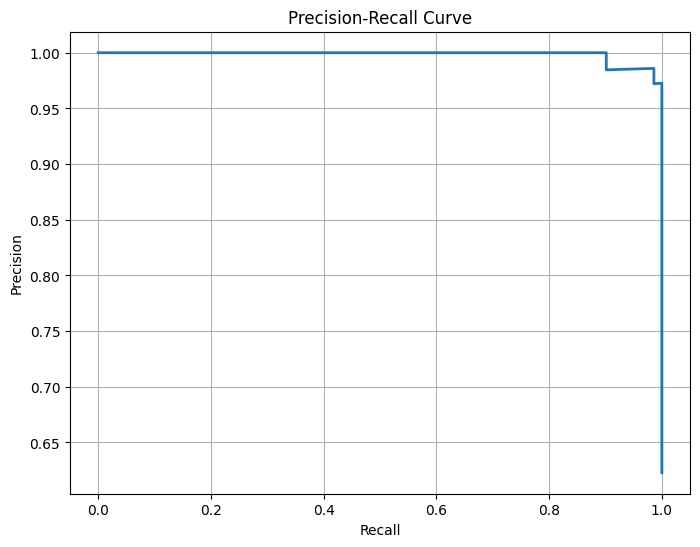

In [7]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_c_test,
    y_c_test_proba
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid(True)
plt.show()

Pada kasus deteksi kanker payudara, recall lebih diprioritaskan dibanding precision karena tujuan utama adalah meminimalkan jumlah False Negative, yaitu pasien yang sebenarnya menderita kanker tetapi diprediksi sehat. Konsekuensi False Negative jauh lebih serius dibanding False Positive karena dapat menyebabkan keterlambatan diagnosis dan pengobatan. Oleh karena itu threshold sering diturunkan untuk meningkatkan recall meskipun precision dapat sedikit menurun.